In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, MinMaxScaler

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
pd.set_option("display.max_columns", None)

print("Libraries imported successfully ✅")

Libraries imported successfully ✅


In [3]:
!pip install Faker

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 30.4 MB/s eta 0:00:00


In [4]:
# ------------------------------------------------------------------
# Generates a synthetic MESSY e-commerce returns dataset for practice.
# Skip / delete this cell if you are using your own uploaded CSV instead.
# ------------------------------------------------------------------
from faker import Faker
import random

fake = Faker()
Faker.seed(42); np.random.seed(42); random.seed(42)

N = 6000  # number of raw order records

categories = ["Electronics", "Fashion", "Home & Kitchen", "Beauty",
              "Sports", "Toys", "Books", "Grocery"]
category_variants = {
    "Electronics": ["Electronics", "electronics", "ELECTRONICS", "Electronics "],
    "Fashion": ["Fashion", "fashion", "Fashion "],
    "Home & Kitchen": ["Home & Kitchen", "home & kitchen", "Home & kitchen"],
    "Beauty": ["Beauty", "beauty", " Beauty"],
    "Sports": ["Sports", "sports"],
    "Toys": ["Toys", "toys"],
    "Books": ["Books", "books"],
    "Grocery": ["Grocery", "grocery"],
}
payment_methods = ["Credit Card", "Debit Card", "UPI", "Net Banking", "Cash on Delivery"]
regions = ["North", "South", "East", "West", "Central"]
return_reasons = ["Defective Product", "Wrong Item Delivered", "Size Issue",
                   "Changed Mind", "Better Price Found", "Late Delivery", "Not as Described"]

rows = []
for i in range(N):
    cat = random.choice(categories)
    cat_text = random.choice(category_variants[cat])
    base_price = {"Electronics": 8000, "Fashion": 1200, "Home & Kitchen": 2500, "Beauty": 700,
                  "Sports": 1800, "Toys": 900, "Books": 400, "Grocery": 300}[cat]
    price = max(round(np.random.normal(base_price, base_price * 0.35), 2), 50)
    quantity = np.random.choice([1, 1, 1, 2, 2, 3, 4], p=[0.35, 0.2, 0.15, 0.1, 0.1, 0.06, 0.04])
    discount_pct = round(np.random.choice([0, 5, 10, 15, 20, 25, 30],
                                           p=[0.3, 0.15, 0.15, 0.15, 0.1, 0.1, 0.05]), 2)
    is_returned = np.random.choice([0, 1], p=[0.78, 0.22])
    return_reason = random.choice(return_reasons) if is_returned else np.nan
    order_date = fake.date_between(start_date="-2y", end_date="today")
    date_fmt = random.choice(["%Y-%m-%d", "%d/%m/%Y", "%m-%d-%Y"])
    order_date_str = order_date.strftime(date_fmt)
    shipping_cost = round(np.random.gamma(2, 40), 2)
    delivery_days = max(int(np.random.normal(5, 2)), 1)
    customer_age = max(int(np.random.normal(34, 11)), 16)
    rating = np.random.choice([1, 2, 3, 4, 5], p=[0.07, 0.08, 0.15, 0.35, 0.35])

    rows.append({
        "order_id": f"ORD{100000+i}", "customer_id": f"CUST{fake.random_int(min=1000, max=4500)}",
        "product_category": cat_text, "order_date": order_date_str, "price": price,
        "quantity": quantity, "discount_pct": discount_pct, "shipping_cost": shipping_cost,
        "payment_method": random.choice(payment_methods), "region": random.choice(regions),
        "delivery_days": delivery_days, "customer_age": customer_age,
        "customer_rating": rating, "is_returned": is_returned, "return_reason": return_reason,
    })

raw_df = pd.DataFrame(rows)

# inject missing values
for col, frac in [("price", 0.03), ("shipping_cost", 0.04), ("customer_age", 0.05),
                   ("customer_rating", 0.02), ("payment_method", 0.015),
                   ("delivery_days", 0.02), ("product_category", 0.01)]:
    idx = raw_df.sample(frac=frac, random_state=hash(col) % 1000).index
    raw_df.loc[idx, col] = np.nan

# inject outliers
raw_df.loc[raw_df.sample(n=40, random_state=1).index, "price"] *= np.random.uniform(8, 15)
raw_df.loc[raw_df.sample(n=25, random_state=2).index, "delivery_days"] = np.random.randint(40, 90, 25)
raw_df.loc[raw_df.sample(n=20, random_state=3).index, "quantity"] = np.random.randint(25, 60, 20)

# inject duplicate rows
raw_df = pd.concat([raw_df, raw_df.sample(n=150, random_state=4)], ignore_index=True)
raw_df = raw_df.sample(frac=1, random_state=7).reset_index(drop=True)

raw_df.to_csv("ecommerce_returns_raw.csv", index=False)
print("Raw messy dataset generated ->", raw_df.shape)

Raw messy dataset generated -> (6150, 15)


In [6]:
# Load the raw dataset (this is the "Load raw e-commerce dataset" task)
df = pd.read_csv("ecommerce_returns_raw.csv")
print("Shape:", df.shape)
df.head()

Shape: (6150, 15)


,order_id,customer_id,product_category,order_date,price,quantity,discount_pct,shipping_cost,payment_method,region,delivery_days,customer_age,customer_rating,is_returned,return_reason
0,ORD101260,CUST3996,Beauty,06/02/2025,812.51,2,0,86.97,Debit Card,East,2.0,49.0,4.0,0,NaN
1,ORD102354,CUST3212,beauty,05-28-2025,766.01,3,25,8.38,UPI,South,4.0,61.0,3.0,1,Late Delivery
2,ORD105391,CUST1662,Toys,2026-04-24,738.58,1,25,103.45,Credit Card,South,1.0,17.0,3.0,0,NaN
3,ORD100305,CUST4061,Books,2025-06-21,633.00,1,5,111.53,Debit Card,Central,4.0,16.0,5.0,0,NaN
4,ORD103519,CUST1204,Toys,22/12/2024,786.59,2,15,NaN,UPI,North,3.0,34.0,3.0,0,NaN


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6150 entries, 0 to 6149
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          6150 non-null   object 
 1   customer_id       6150 non-null   object 
 2   product_category  6089 non-null   object 
 3   order_date        6150 non-null   object 
 4   price             5964 non-null   float64
 5   quantity          6150 non-null   int64  
 6   discount_pct      6150 non-null   int64  
 7   shipping_cost     5905 non-null   float64
 8   payment_method    6057 non-null   object 
 9   region            6150 non-null   object 
 10  delivery_days     6028 non-null   float64
 11  customer_age      5839 non-null   float64
 12  customer_rating   6028 non-null   float64
 13  is_returned       6150 non-null   int64  
 14  return_reason     1319 non-null   object 
dtypes: float64(5), int64(3), object(7)
memory usage: 720.8+ KB


In [8]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
order_id,6150,6000,ORD105539,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
customer_id,6150,2851,CUST1608,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN
product_category,6089,21,Books,408,NaN,NaN,NaN,NaN,NaN,NaN,NaN
order_date,6150,2064,2025-04-05,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN
price,5964.0,NaN,NaN,NaN,2099.316026,3481.263272,50.0,478.945,1008.355,2153.515,126578.903504
quantity,6150.0,NaN,NaN,NaN,1.54374,2.346464,1.0,1.0,1.0,2.0,58.0
discount_pct,6150.0,NaN,NaN,NaN,10.356098,9.412055,0.0,0.0,10.0,15.0,30.0
shipping_cost,5905.0,NaN,NaN,NaN,80.092467,56.760752,1.07,37.76,67.27,107.16,443.25
payment_method,6057,5,UPI,1258,NaN,NaN,NaN,NaN,NaN,NaN,NaN
region,6150,5,North,1250,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
print("Missing values per column:\n")
print(df.isna().sum())

print("\nTotal duplicate rows:", df.duplicated().sum())

Missing values per column:

order_id               0
customer_id            0
product_category      61
order_date             0
price                186
quantity               0
discount_pct           0
shipping_cost        245
payment_method        93
region                 0
delivery_days        122
customer_age         311
customer_rating      122
is_returned            0
return_reason       4831
dtype: int64

Total duplicate rows: 150


In [10]:
# Standardize category text: strip whitespace + Title Case
df["product_category"] = df["product_category"].str.strip().str.title()
print(df["product_category"].value_counts())

product_category
Home & Kitchen    829
Books             807
Electronics       772
Toys              766
Beauty            765
Grocery           721
Fashion           718
Sports            711
Name: count, dtype: int64


In [11]:
# Parse mixed date formats into a single proper datetime column
def parse_date(x):
    for fmt in ("%Y-%m-%d", "%d/%m/%Y", "%m-%d-%Y"):
        try:
            return pd.to_datetime(x, format=fmt)
        except Exception:
            continue
    return pd.NaT

df["order_date"] = df["order_date"].apply(parse_date)
df["order_date"].head()

,order_date
0,2025-02-06
1,2025-05-28
2,2026-04-24
3,2025-06-21
4,2024-12-22


In [12]:
dupe_count = df.duplicated().sum()
print(f"Found {dupe_count} duplicate rows")

df = df.drop_duplicates().reset_index(drop=True)
print("Shape after removing duplicates:", df.shape)

Found 150 duplicate rows
Shape after removing duplicates: (6000, 15)


In [13]:
print("Missing values BEFORE imputation:")
print(df.isna().sum())

Missing values BEFORE imputation:
order_id               0
customer_id            0
product_category      60
order_date             0
price                180
quantity               0
discount_pct           0
shipping_cost        240
payment_method        90
region                 0
delivery_days        119
customer_age         300
customer_rating      120
is_returned            0
return_reason       4706
dtype: int64


In [14]:
# Numeric columns -> median imputation
num_cols = ["price", "shipping_cost", "delivery_days", "customer_age", "customer_rating"]
for c in num_cols:
    median_val = df[c].median()
    df[c] = df[c].fillna(median_val)
    print(f"{c}: filled missing with median = {median_val}")

# Categorical columns -> mode imputation
df["product_category"] = df["product_category"].fillna(df["product_category"].mode()[0])
df["payment_method"] = df["payment_method"].fillna(df["payment_method"].mode()[0])

# return_reason -> missing means "not returned", so it's informative, not lost data
df["return_reason"] = df["return_reason"].fillna("Not Returned")

price: filled missing with median = 1009.15
shipping_cost: filled missing with median = 67.03
delivery_days: filled missing with median = 5.0
customer_age: filled missing with median = 34.0
customer_rating: filled missing with median = 4.0


In [15]:
print("Missing values AFTER imputation:")
print(df.isna().sum())
print("\nTotal remaining missing values:", df.isna().sum().sum())

Missing values AFTER imputation:
order_id            0
customer_id         0
product_category    0
order_date          0
price               0
quantity            0
discount_pct        0
shipping_cost       0
payment_method      0
region              0
delivery_days       0
customer_age        0
customer_rating     0
is_returned         0
return_reason       0
dtype: int64

Total remaining missing values: 0


In [16]:
def detect_outliers_iqr(series):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_outliers = ((series < lower) | (series > upper)).sum()
    return lower, upper, n_outliers

outlier_cols = ["price", "delivery_days", "quantity", "shipping_cost"]
for c in outlier_cols:
    lower, upper, n = detect_outliers_iqr(df[c])
    print(f"{c}: {n} outliers detected (bounds: {lower:.1f} to {upper:.1f})")

price: 701 outliers detected (bounds: -1933.0 to 4530.5)
delivery_days: 27 outliers detected (bounds: -1.5 to 10.5)
quantity: 239 outliers detected (bounds: -0.5 to 3.5)
shipping_cost: 231 outliers detected (bounds: -59.5 to 203.3)


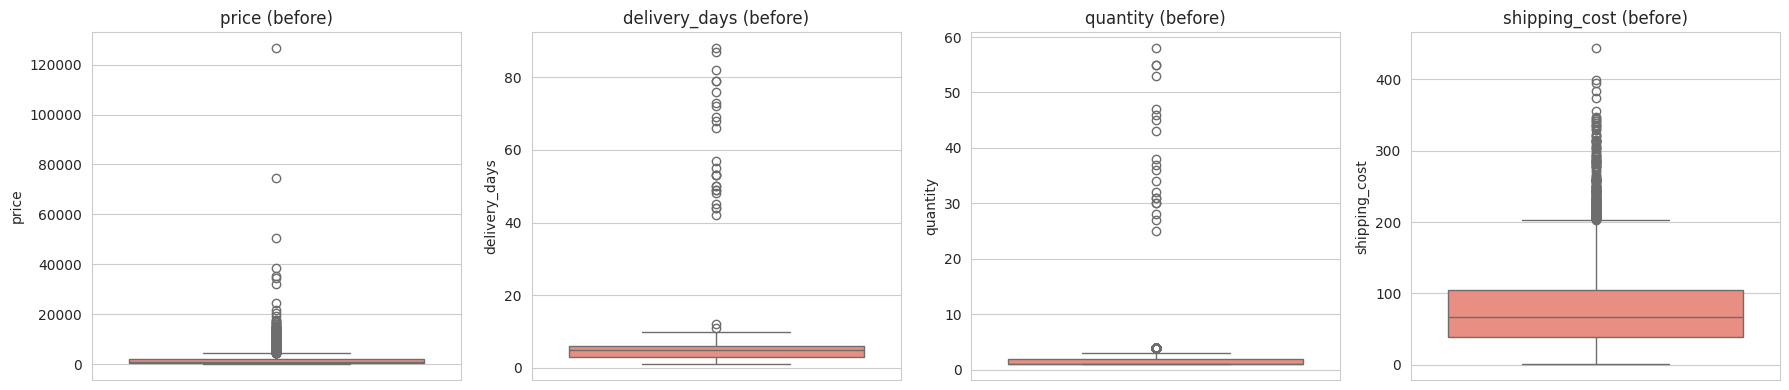

In [17]:
# Visualize outliers BEFORE treatment
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, c in zip(axes, outlier_cols):
    sns.boxplot(y=df[c], ax=ax, color="salmon")
    ax.set_title(f"{c} (before)")
plt.tight_layout()
plt.show()

In [18]:
# Treat outliers by clipping to the IQR bounds
def iqr_clip(series):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return series.clip(lower, upper)

for c in outlier_cols:
    df[c] = iqr_clip(df[c])

print("Outliers treated ✅")

Outliers treated ✅


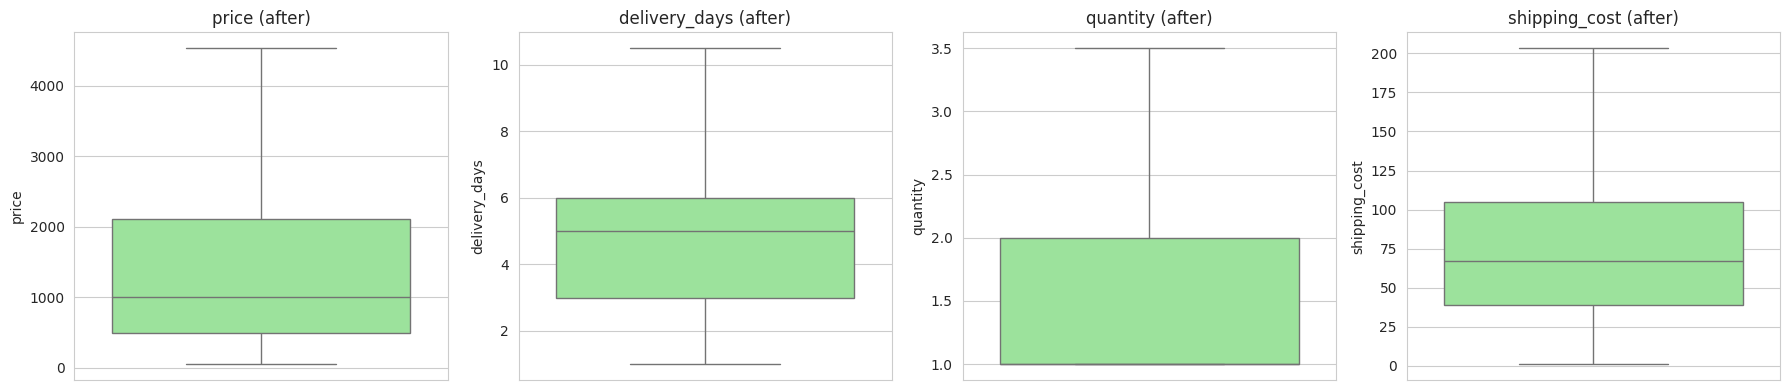

In [19]:
# Visualize AFTER treatment
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, c in zip(axes, outlier_cols):
    sns.boxplot(y=df[c], ax=ax, color="lightgreen")
    ax.set_title(f"{c} (after)")
plt.tight_layout()
plt.show()

In [20]:
df["order_value"] = df["price"] * df["quantity"] * (1 - df["discount_pct"] / 100)
df["order_month"] = df["order_date"].dt.to_period("M").astype(str)
df[["price", "quantity", "discount_pct", "order_value", "order_month"]].head()

,price,quantity,discount_pct,order_value,order_month
0,812.51,2.0,0,1625.0200,2025-02
1,766.01,3.0,25,1723.5225,2025-05
2,738.58,1.0,25,553.9350,2026-04
3,633.00,1.0,5,601.3500,2025-06
4,786.59,2.0,15,1337.2030,2024-12


In [21]:
df_encoded = df.copy()

# Label Encoding for payment_method & region
le = LabelEncoder()
for c in ["payment_method", "region"]:
    df_encoded[c + "_enc"] = le.fit_transform(df_encoded[c])

# One-Hot Encoding for product_category
df_encoded = pd.get_dummies(df_encoded, columns=["product_category"], prefix="cat")

print("Encoded columns added. New shape:", df_encoded.shape)
df_encoded.filter(regex="_enc|^cat_").head()

Encoded columns added. New shape: (6000, 26)


,payment_method_enc,region_enc,cat_Beauty,cat_Books,cat_Electronics,cat_Fashion,cat_Grocery,cat_Home & Kitchen,cat_Sports,cat_Toys
0,2,1,True,False,False,False,False,False,False,False
1,4,3,True,False,False,False,False,False,False,False
2,1,3,False,False,False,False,False,False,False,True
3,2,0,False,True,False,False,False,False,False,False
4,4,2,False,False,False,False,False,False,False,True


In [22]:
scaler = MinMaxScaler()
scale_cols = ["price", "shipping_cost", "delivery_days", "customer_age", "order_value"]
normalized = scaler.fit_transform(df_encoded[scale_cols])

for i, c in enumerate(scale_cols):
    df_encoded[c + "_norm"] = normalized[:, i]

df_encoded.filter(regex="_norm").describe()

,price_norm,shipping_cost_norm,delivery_days_norm,customer_age_norm,order_value_norm
count,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000
mean,0.332296,0.378835,0.376798,0.298881,0.122876
std,0.307054,0.246988,0.206671,0.171916,0.143379
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.098381,0.187681,0.210526,0.183333,0.032519
50%,0.214070,0.326139,0.421053,0.300000,0.067721
75%,0.459028,0.512608,0.526316,0.416667,0.162190
max,1.000000,1.000000,1.000000,1.000000,1.000000


Overall return rate: 21.57%


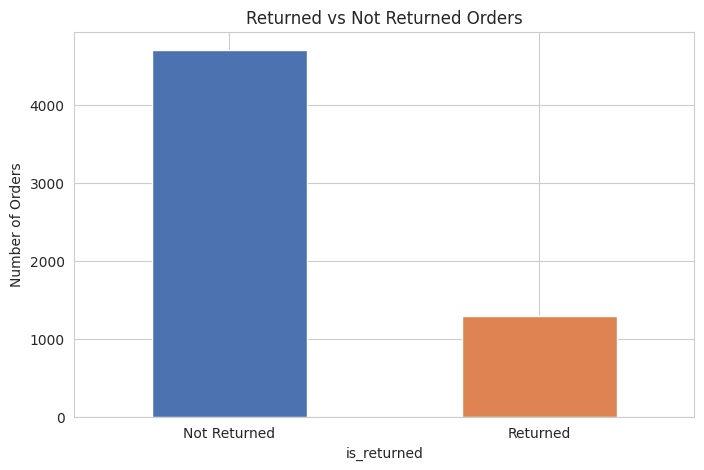

In [23]:
# Overall return rate
overall_return_rate = df["is_returned"].mean() * 100
print(f"Overall return rate: {overall_return_rate:.2f}%")

plt.figure()
df["is_returned"].value_counts().plot(kind="bar", color=["#4C72B0", "#DD8452"])
plt.xticks([0, 1], ["Not Returned", "Returned"], rotation=0)
plt.ylabel("Number of Orders")
plt.title("Returned vs Not Returned Orders")
plt.show()

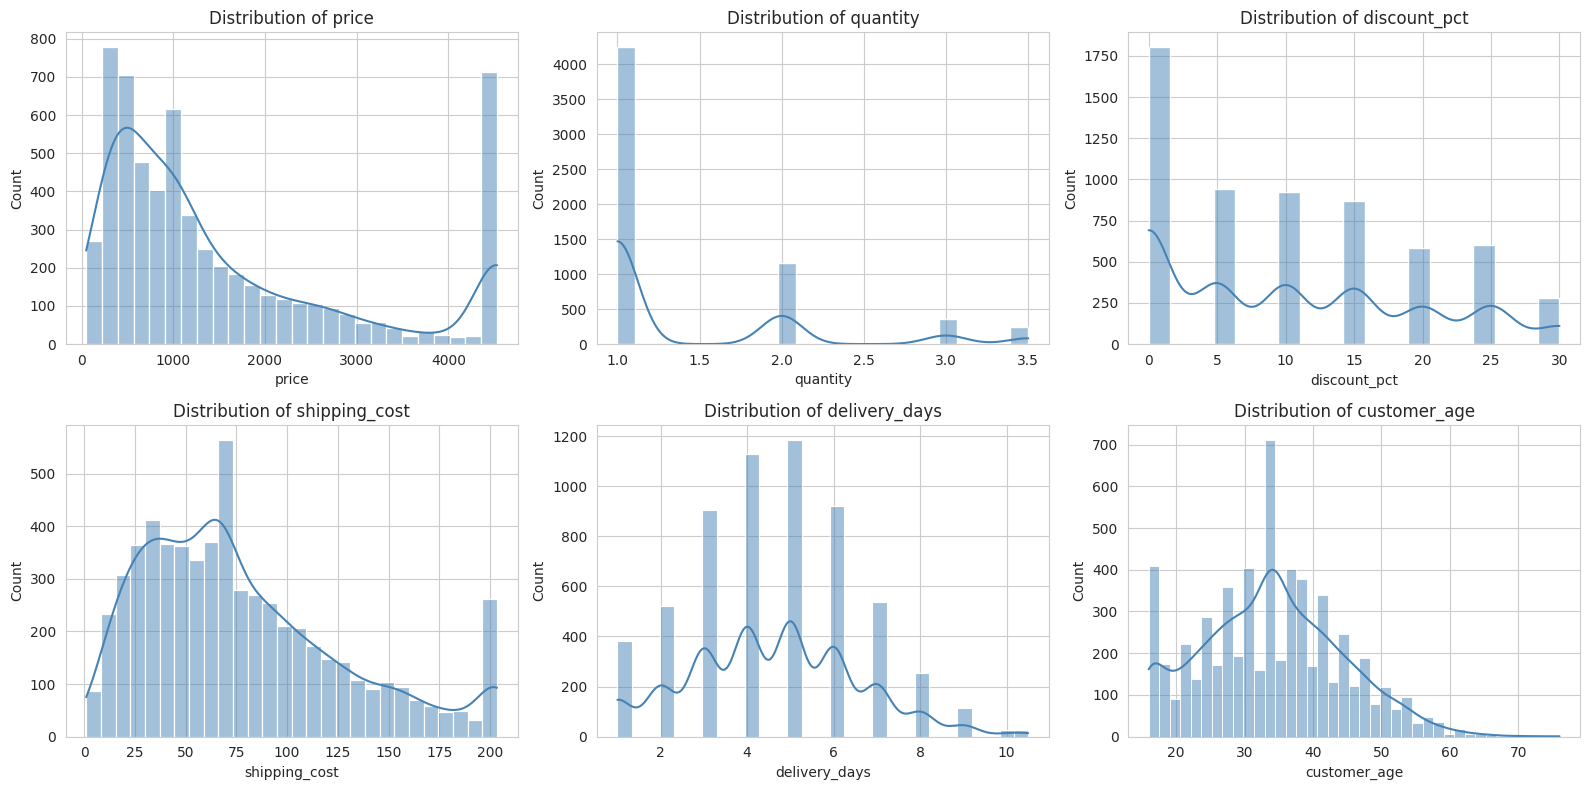

In [24]:
# Distribution of numeric features
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
num_features = ["price", "quantity", "discount_pct", "shipping_cost", "delivery_days", "customer_age"]
for ax, c in zip(axes.flatten(), num_features):
    sns.histplot(df[c], kde=True, ax=ax, color="steelblue")
    ax.set_title(f"Distribution of {c}")
plt.tight_layout()
plt.show()

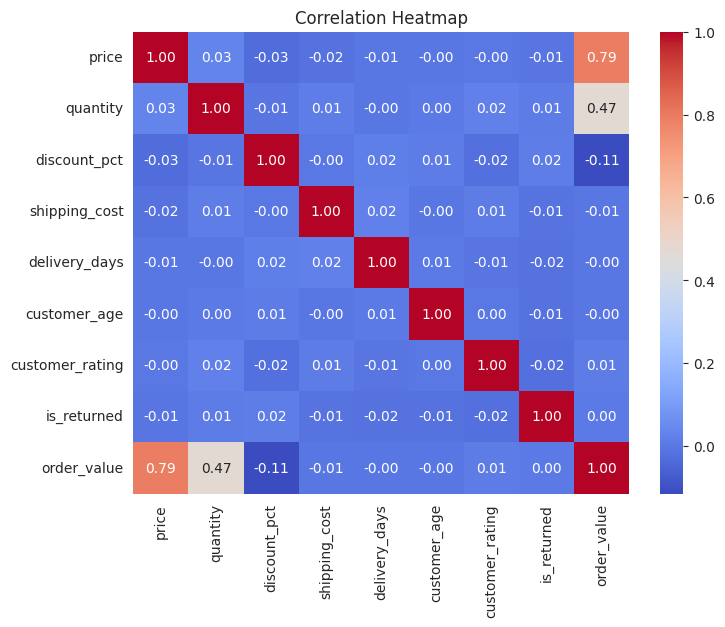

In [25]:
# Correlation heatmap between numeric features
plt.figure(figsize=(8, 6))
num_cols = ["price", "quantity", "discount_pct", "shipping_cost", "delivery_days",
            "customer_age", "customer_rating", "is_returned", "order_value"]
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

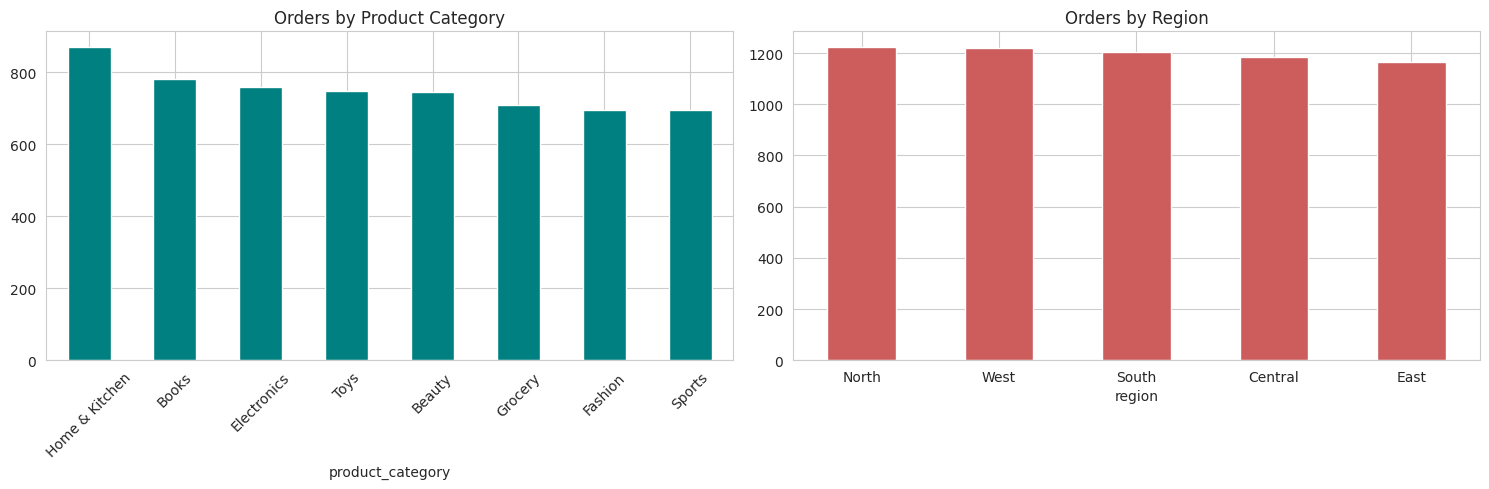

In [26]:
# Orders by category and region
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
df["product_category"].value_counts().plot(kind="bar", ax=axes[0], color="teal")
axes[0].set_title("Orders by Product Category")
axes[0].tick_params(axis="x", rotation=45)

df["region"].value_counts().plot(kind="bar", ax=axes[1], color="indianred")
axes[1].set_title("Orders by Region")
axes[1].tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

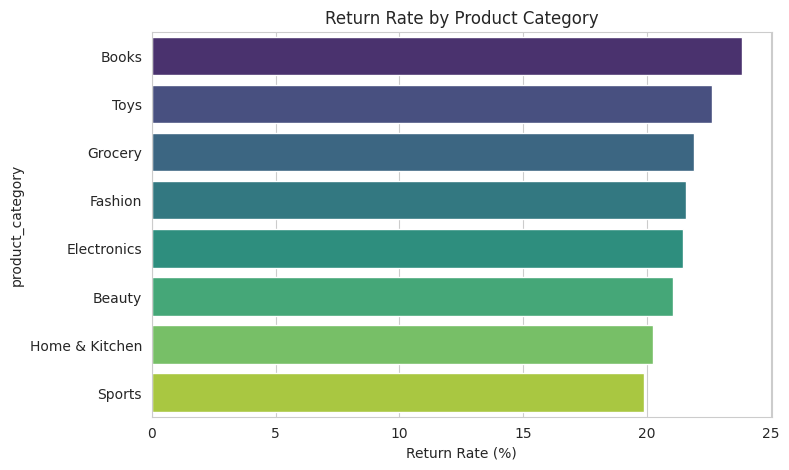

product_category
Books             23.846154
Toys              22.623829
Grocery           21.892655
Fashion           21.582734
Electronics       21.447368
Beauty            21.045576
Home & Kitchen    20.229885
Sports            19.884726
Name: is_returned, dtype: float64


In [27]:
cat_return = df.groupby("product_category")["is_returned"].mean().sort_values(ascending=False) * 100

plt.figure()
sns.barplot(x=cat_return.values, y=cat_return.index, hue=cat_return.index,
            palette="viridis", legend=False)
plt.xlabel("Return Rate (%)")
plt.title("Return Rate by Product Category")
plt.show()

print(cat_return)

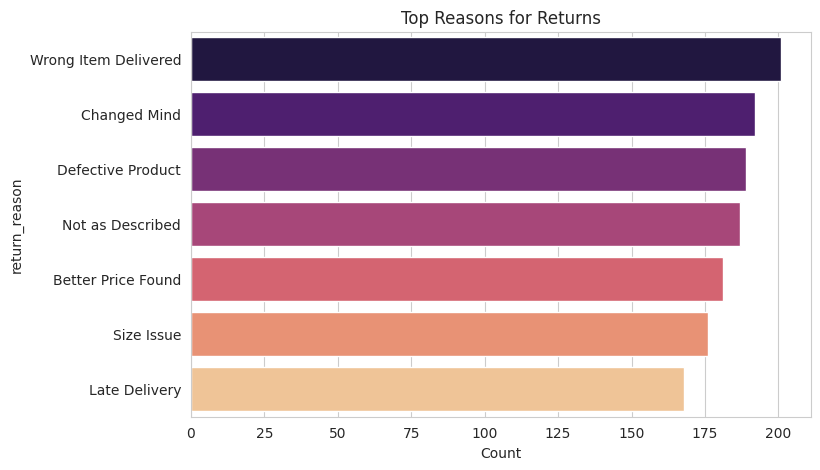

return_reason
Wrong Item Delivered    201
Changed Mind            192
Defective Product       189
Not as Described        187
Better Price Found      181
Size Issue              176
Late Delivery           168
Name: count, dtype: int64


In [28]:
reasons = df[df["is_returned"] == 1]["return_reason"].value_counts()

plt.figure()
sns.barplot(x=reasons.values, y=reasons.index, hue=reasons.index, palette="magma", legend=False)
plt.xlabel("Count")
plt.title("Top Reasons for Returns")
plt.show()

print(reasons)

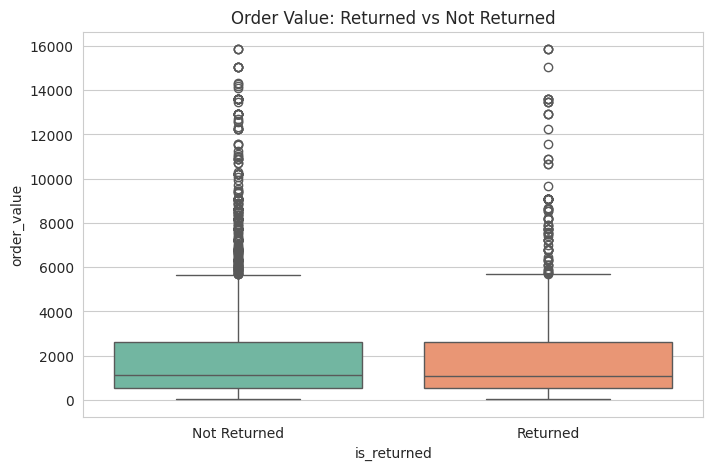

is_returned
0    1115.9800
1    1081.1185
Name: order_value, dtype: float64


In [29]:
plt.figure()
sns.boxplot(data=df, x="is_returned", y="order_value", hue="is_returned", palette="Set2", legend=False)
plt.xticks([0, 1], ["Not Returned", "Returned"])
plt.title("Order Value: Returned vs Not Returned")
plt.show()

print(df.groupby("is_returned")["order_value"].median())

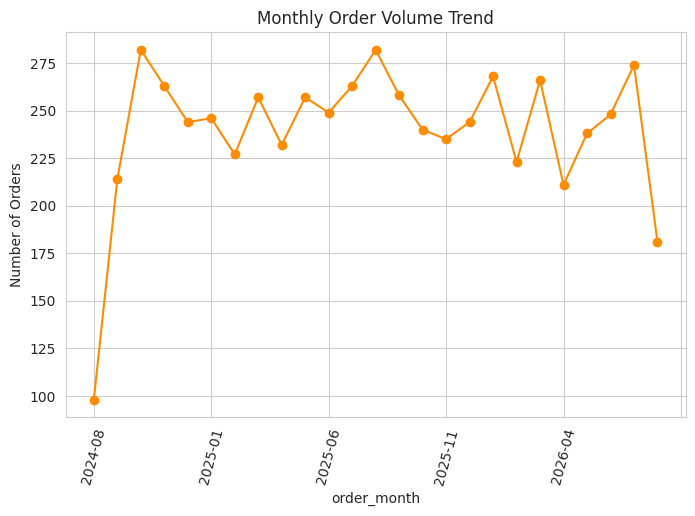

In [30]:
monthly = df.groupby("order_month").size()

plt.figure()
monthly.plot(kind="line", marker="o", color="darkorange")
plt.xticks(rotation=75)
plt.ylabel("Number of Orders")
plt.title("Monthly Order Volume Trend")
plt.show()

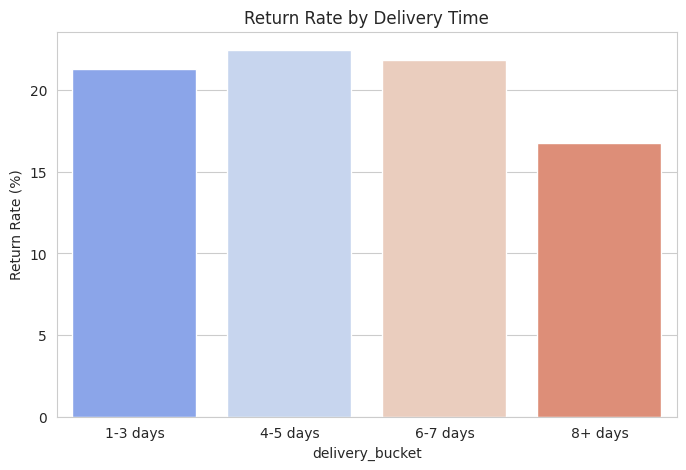

delivery_bucket
1-3 days    21.317829
4-5 days    22.471910
6-7 days    21.825669
8+ days     16.784870
Name: is_returned, dtype: float64


In [31]:
df["delivery_bucket"] = pd.cut(df["delivery_days"], bins=[0, 3, 5, 7, 100],
                                labels=["1-3 days", "4-5 days", "6-7 days", "8+ days"])
delivery_return = df.groupby("delivery_bucket", observed=True)["is_returned"].mean() * 100

plt.figure()
sns.barplot(x=delivery_return.index.astype(str), y=delivery_return.values,
            hue=delivery_return.index.astype(str), palette="coolwarm", legend=False)
plt.ylabel("Return Rate (%)")
plt.title("Return Rate by Delivery Time")
plt.show()

print(delivery_return)

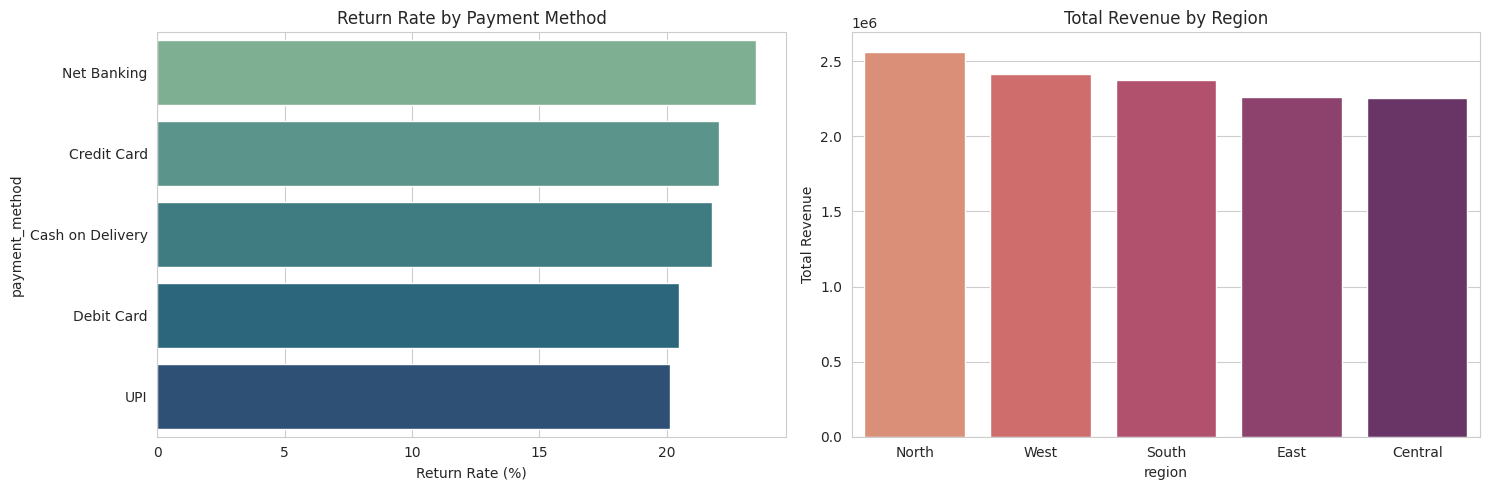

payment_method
Net Banking         23.494487
Credit Card         22.073579
Cash on Delivery    21.795990
Debit Card          20.501730
UPI                 20.121029
Name: is_returned, dtype: float64 

region
North      2.564109e+06
West       2.417989e+06
South      2.375201e+06
East       2.260846e+06
Central    2.256605e+06
Name: order_value, dtype: float64


In [32]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

pay_return = df.groupby("payment_method")["is_returned"].mean().sort_values(ascending=False) * 100
sns.barplot(x=pay_return.values, y=pay_return.index, hue=pay_return.index,
            palette="crest", legend=False, ax=axes[0])
axes[0].set_xlabel("Return Rate (%)")
axes[0].set_title("Return Rate by Payment Method")

region_rev = df.groupby("region")["order_value"].sum().sort_values(ascending=False)
sns.barplot(x=region_rev.index, y=region_rev.values, hue=region_rev.index,
            palette="flare", legend=False, ax=axes[1])
axes[1].set_ylabel("Total Revenue")
axes[1].set_title("Total Revenue by Region")

plt.tight_layout()
plt.show()

print(pay_return, "\n")
print(region_rev)

In [34]:
df.to_csv("ecommerce_returns_cleaned.csv", index=False)
df_encoded.to_csv("ecommerce_returns_encoded.csv", index=False)

print("Cleaned dataset saved as ecommerce_returns_cleaned.csv  ->", df.shape)
print("Encoded/normalized dataset saved as ecommerce_returns_encoded.csv ->", df_encoded.shape)

Cleaned dataset saved as ecommerce_returns_cleaned.csv  -> (6000, 18)
Encoded/normalized dataset saved as ecommerce_returns_encoded.csv -> (6000, 31)


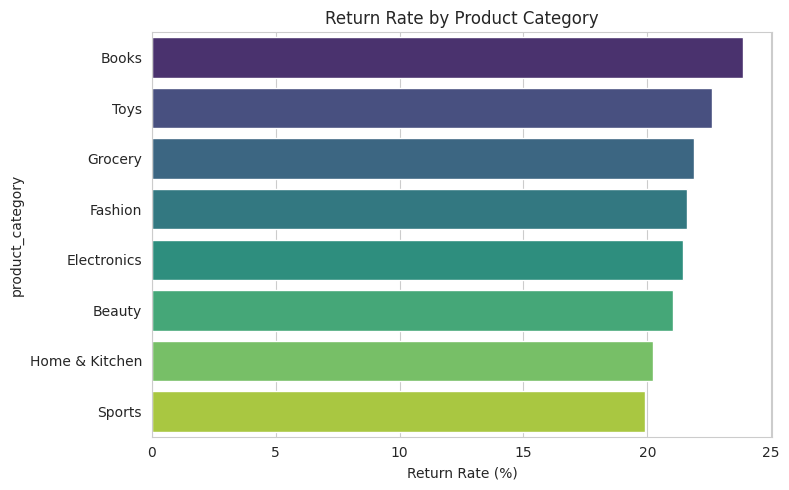

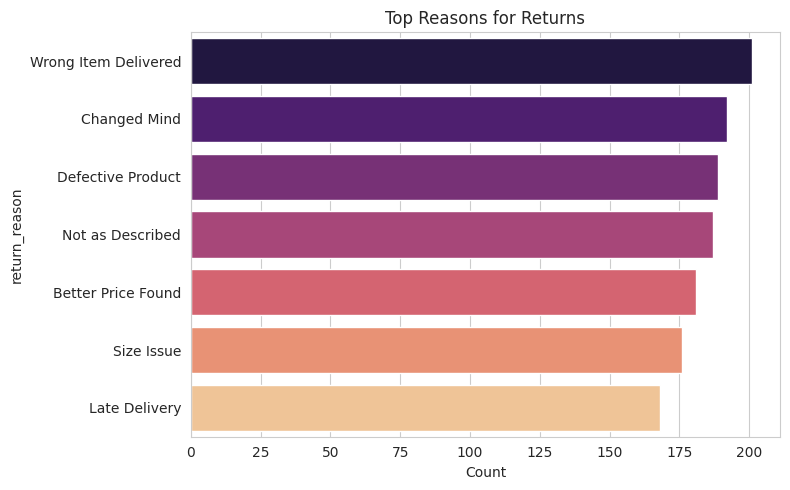

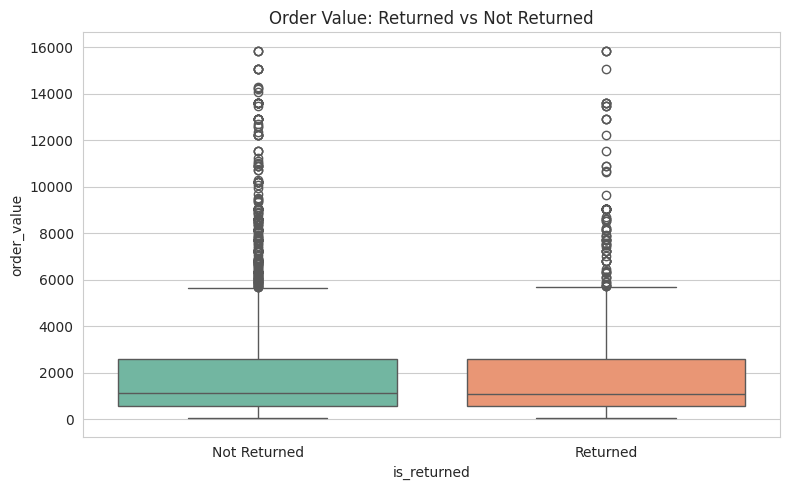

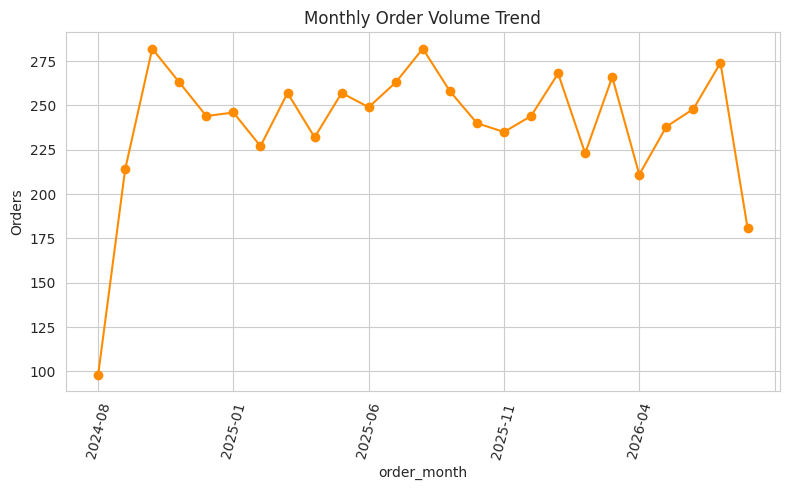

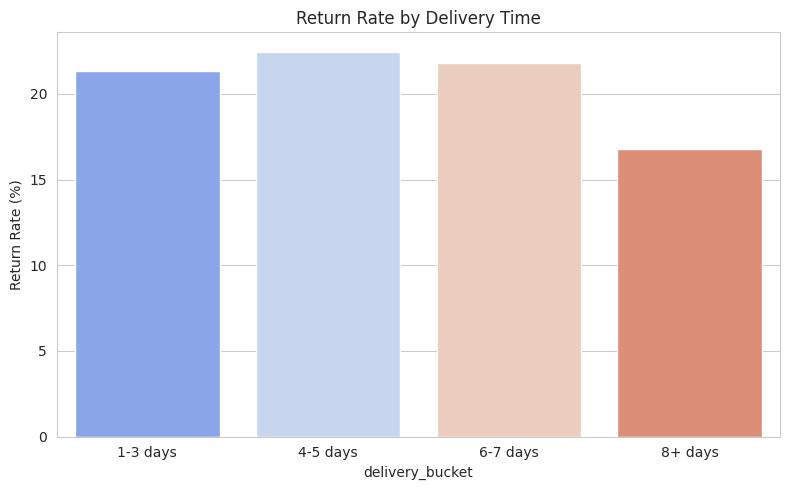

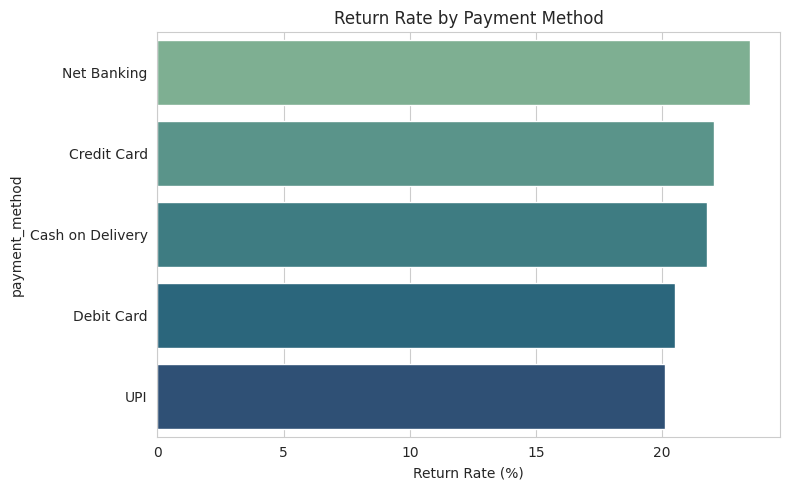

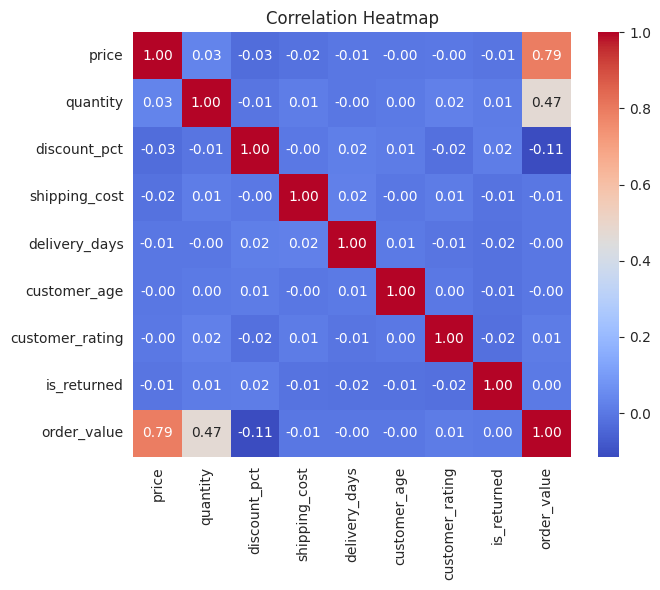

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [35]:
import os, shutil
import matplotlib.pyplot as plt
import seaborn as sns

os.makedirs("charts", exist_ok=True)

cat_return = df.groupby("product_category")["is_returned"].mean().sort_values(ascending=False) * 100
plt.figure()
sns.barplot(x=cat_return.values, y=cat_return.index, hue=cat_return.index, palette="viridis", legend=False)
plt.xlabel("Return Rate (%)"); plt.title("Return Rate by Product Category")
plt.tight_layout(); plt.savefig("charts/insight1_return_rate_category.png", dpi=150); plt.show()

reasons = df[df["is_returned"] == 1]["return_reason"].value_counts()
plt.figure()
sns.barplot(x=reasons.values, y=reasons.index, hue=reasons.index, palette="magma", legend=False)
plt.xlabel("Count"); plt.title("Top Reasons for Returns")
plt.tight_layout(); plt.savefig("charts/insight2_return_reasons.png", dpi=150); plt.show()

plt.figure()
sns.boxplot(data=df, x="is_returned", y="order_value", hue="is_returned", palette="Set2", legend=False)
plt.xticks([0, 1], ["Not Returned", "Returned"]); plt.title("Order Value: Returned vs Not Returned")
plt.tight_layout(); plt.savefig("charts/insight3_order_value_vs_return.png", dpi=150); plt.show()

plt.figure()
df.groupby("order_month").size().plot(kind="line", marker="o", color="darkorange")
plt.xticks(rotation=75); plt.ylabel("Orders"); plt.title("Monthly Order Volume Trend")
plt.tight_layout(); plt.savefig("charts/insight4_monthly_trend.png", dpi=150); plt.show()

delivery_return = df.groupby("delivery_bucket", observed=True)["is_returned"].mean() * 100
plt.figure()
sns.barplot(x=delivery_return.index.astype(str), y=delivery_return.values,
            hue=delivery_return.index.astype(str), palette="coolwarm", legend=False)
plt.ylabel("Return Rate (%)"); plt.title("Return Rate by Delivery Time")
plt.tight_layout(); plt.savefig("charts/insight5_delivery_vs_return.png", dpi=150); plt.show()

pay_return = df.groupby("payment_method")["is_returned"].mean().sort_values(ascending=False) * 100
plt.figure()
sns.barplot(x=pay_return.values, y=pay_return.index, hue=pay_return.index, palette="crest", legend=False)
plt.xlabel("Return Rate (%)"); plt.title("Return Rate by Payment Method")
plt.tight_layout(); plt.savefig("charts/insight6_payment_vs_return.png", dpi=150); plt.show()

plt.figure(figsize=(7, 6))
num_cols = ["price", "quantity", "discount_pct", "shipping_cost", "delivery_days",
            "customer_age", "customer_rating", "is_returned", "order_value"]
sns.heatmap(df[num_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.tight_layout(); plt.savefig("charts/correlation_heatmap.png", dpi=150); plt.show()

shutil.make_archive("ecommerce_charts", "zip", "charts")

from google.colab import files
files.download("ecommerce_charts.zip")